In [1]:

!pip install lightly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 859.3/859.3 kB 27.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 165.6/165.6 kB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 95.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 51.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 31.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [2]:
# ============================
# Full SimCLR Pipeline (like MoCo)
# ============================

import os, shutil, random
from glob import glob
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from lightly.loss import NTXentLoss

device = "cuda" if torch.cuda.is_available() else "cpu"

# -----------------------------
# 1️⃣ Dataset split (Raw + Raw Data only)
# -----------------------------
root_dir = "/kaggle/input/fish-classification-dataset/Fish Data/Fish Data"
working_dir = "/kaggle/working/fish_dataset_split_simclr"

train_ratio, val_ratio, test_ratio = 0.7, 0.15, 0.15
splits = ["train", "val", "test"]

os.makedirs(working_dir, exist_ok=True)
for s in splits:
    os.makedirs(os.path.join(working_dir, s), exist_ok=True)

# Only split if empty
needs_split = any(len(os.listdir(os.path.join(working_dir, s))) == 0 for s in splits)

if needs_split:
    for cls in os.listdir(root_dir):
        class_dir = os.path.join(root_dir, cls)
        if not os.path.isdir(class_dir):
            continue
        raw_folders = ["Raw", "Raw Data"]
        images = []
        for rf in raw_folders:
            path = os.path.join(class_dir, rf)
            if os.path.exists(path):
                images.extend([p for p in glob(os.path.join(path, "*")) if os.path.isfile(p)])
        if len(images) == 0:
            continue

        random.shuffle(images)
        n = len(images)
        n_train = int(n * train_ratio)
        n_val = int(n * val_ratio)
        n_test = n - n_train - n_val

        assigns = {
            "train": images[:n_train],
            "val": images[n_train:n_train + n_val],
            "test": images[n_train + n_val:]
        }

        for s in splits:
            dest_dir = os.path.join(working_dir, s, cls)
            os.makedirs(dest_dir, exist_ok=True)
            for p in assigns[s]:
                try:
                    shutil.copy(p, dest_dir)
                except:
                    pass
    print("✅ Dataset split created in:", working_dir)
else:
    print("ℹ️ Using existing split in:", working_dir)

✅ Dataset split created in: /kaggle/working/fish_dataset_split_simclr


In [3]:
# -----------------------------
# 2️⃣ Pretraining Dataset + Augmentations
# -----------------------------
simclr_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(0.8, 0.8, 0.8, 0.2),
    transforms.RandomGrayscale(p=0.2),
    transforms.GaussianBlur(kernel_size=3),
    transforms.ToTensor(),
])

train_dataset = datasets.ImageFolder(os.path.join(working_dir, "train"), transform=simclr_transform)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True, drop_last=True)

# -----------------------------
# 3️⃣ Backbone + Projection Head
# -----------------------------
backbone = models.resnet18(pretrained=False)
backbone.fc = nn.Identity()

class SimCLR(nn.Module):
    def __init__(self, backbone, num_ftrs=512, projection_dim=128):
        super().__init__()
        self.backbone = backbone
        self.projection = nn.Sequential(
            nn.Linear(num_ftrs, 512),
            nn.ReLU(),
            nn.Linear(512, projection_dim)
        )

    def forward(self, x):
        h = self.backbone(x)
        z = self.projection(h)
        return z

model = SimCLR(backbone).to(device)
criterion = NTXentLoss(temperature=0.5)
optimizer = torch.optim.Adam(model.parameters(), lr=3e-4)

# -----------------------------
# 4️⃣ SimCLR Pretraining
# -----------------------------
epochs_pre = 100
for epoch in range(epochs_pre):
    total_loss = 0
    model.train()
    for images, _ in train_loader:
        x0 = images.to(device)
        x1 = images.to(device)

        z0 = model(x0)
        z1 = model(x1)

        loss = criterion(z0, z1)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs_pre}], SimCLR Loss: {total_loss/len(train_loader):.4f}")

torch.save(backbone.state_dict(), "simclr_backbone.pth")
print("✅ SimCLR pretraining finished and backbone saved!")

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Epoch [1/100], SimCLR Loss: 3.0076
Epoch [2/100], SimCLR Loss: 2.9393
Epoch [3/100], SimCLR Loss: 2.9288
Epoch [4/100], SimCLR Loss: 2.9248
Epoch [5/100], SimCLR Loss: 2.9225
Epoch [6/100], SimCLR Loss: 2.9191
Epoch [7/100], SimCLR Loss: 2.9190
Epoch [8/100], SimCLR Loss: 2.9150
Epoch [9/100], SimCLR Loss: 2.9144
Epoch [10/100], SimCLR Loss: 2.9131
Epoch [11/100], SimCLR Loss: 2.9118
Epoch [12/100], SimCLR Loss: 2.9103
Epoch [13/100], SimCLR Loss: 2.9092
Epoch [14/100], SimCLR Loss: 2.9095
Epoch [15/100], SimCLR Loss: 2.9079
Epoch [16/100], SimCLR Loss: 2.9101
Epoch [17/100], SimCLR Loss: 2.9123
Epoch [18/100], SimCLR Loss: 2.9069
Epoch [19/100], SimCLR Loss: 2.9055
Epoch [20/100], SimCLR Loss: 2.9040
Epoch [21/100], SimCLR Loss: 2.9035
Epoch [22/100], SimCLR Loss: 2.9042
Epoch [23/100], SimCLR Loss: 2.9024
Epoch [24/100], SimCLR Loss: 2.9020
Epoch [25/100], SimCLR Loss: 2.9030
Epoch [26/100], SimCLR Loss: 2.9024
Epoch [27/100], SimCLR Loss: 2.9013
Epoch [28/100], SimCLR Loss: 2.8989
E

In [4]:
# -----------------------------
# 5️⃣ Fine-tuning (like BYOL/MoCo)
# -----------------------------
finetune_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

train_dataset_ft = datasets.ImageFolder(os.path.join(working_dir, "train"), transform=finetune_transform)
val_dataset_ft   = datasets.ImageFolder(os.path.join(working_dir, "val"),   transform=finetune_transform)
test_dataset_ft  = datasets.ImageFolder(os.path.join(working_dir, "test"),  transform=finetune_transform)

train_loader_ft = DataLoader(train_dataset_ft, batch_size=64, shuffle=True)
val_loader_ft   = DataLoader(val_dataset_ft, batch_size=64, shuffle=False)
test_loader_ft  = DataLoader(test_dataset_ft, batch_size=64, shuffle=False)

# Freeze most backbone, unfreeze last 2 layers
for name, param in backbone.named_parameters():
    param.requires_grad = False
    if "layer3" in name or "layer4" in name:
        param.requires_grad = True
backbone.to(device)

num_classes = len(train_dataset_ft.classes)
classifier = nn.Linear(512, num_classes).to(device)

criterion = nn.CrossEntropyLoss()
optimizer_cls = torch.optim.Adam(
    list(classifier.parameters()) +
    [p for p in backbone.parameters() if p.requires_grad],
    lr=1e-4
)
epochs_cls = 50

for epoch in range(epochs_cls):
    classifier.train()
    total_loss = 0
    total_correct = 0

    for images, labels in train_loader_ft:
        images, labels = images.to(device), labels.to(device)
        features = backbone(images)
        outputs = classifier(features)
        loss = criterion(outputs, labels)

        optimizer_cls.zero_grad()
        loss.backward()
        optimizer_cls.step()

        total_loss += loss.item()
        total_correct += (outputs.argmax(1) == labels).sum().item()

    train_acc = total_correct / len(train_dataset_ft)
    print(f"Epoch [{epoch+1}/{epochs_cls}], Loss: {total_loss/len(train_loader_ft):.4f}, Train Acc: {train_acc:.4f}")

    # Validation
    classifier.eval()
    total_correct = 0
    with torch.no_grad():
        for images, labels in val_loader_ft:
            images, labels = images.to(device), labels.to(device)
            features = backbone(images)
            outputs = classifier(features)
            total_correct += (outputs.argmax(1) == labels).sum().item()
    val_acc = total_correct / len(val_dataset_ft)

Epoch [1/50], Loss: 2.2025, Train Acc: 0.3584
Epoch [2/50], Loss: 1.2753, Train Acc: 0.6230
Epoch [3/50], Loss: 0.8377, Train Acc: 0.7532
Epoch [4/50], Loss: 0.5968, Train Acc: 0.8252
Epoch [5/50], Loss: 0.4390, Train Acc: 0.8739
Epoch [6/50], Loss: 0.3521, Train Acc: 0.8980
Epoch [7/50], Loss: 0.2862, Train Acc: 0.9173
Epoch [8/50], Loss: 0.2392, Train Acc: 0.9323
Epoch [9/50], Loss: 0.1938, Train Acc: 0.9450
Epoch [10/50], Loss: 0.1625, Train Acc: 0.9553
Epoch [11/50], Loss: 0.1364, Train Acc: 0.9628
Epoch [12/50], Loss: 0.1208, Train Acc: 0.9669
Epoch [13/50], Loss: 0.1046, Train Acc: 0.9708
Epoch [14/50], Loss: 0.0923, Train Acc: 0.9753
Epoch [15/50], Loss: 0.0789, Train Acc: 0.9785
Epoch [16/50], Loss: 0.0724, Train Acc: 0.9798
Epoch [17/50], Loss: 0.0634, Train Acc: 0.9824
Epoch [18/50], Loss: 0.0542, Train Acc: 0.9850
Epoch [19/50], Loss: 0.0500, Train Acc: 0.9873
Epoch [20/50], Loss: 0.0497, Train Acc: 0.9870
Epoch [21/50], Loss: 0.0426, Train Acc: 0.9883
Epoch [22/50], Loss: 0

✅ Test Accuracy: 0.8747


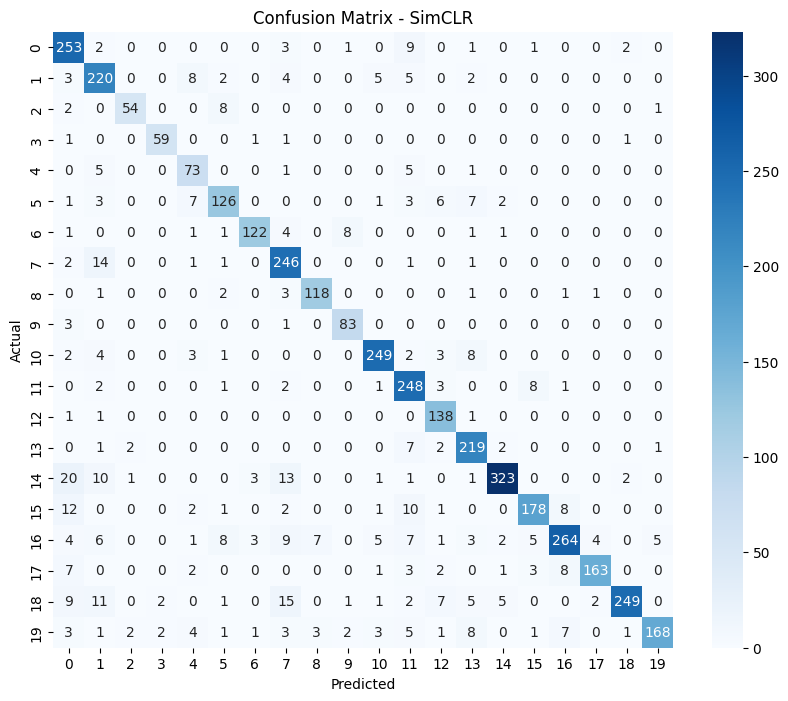

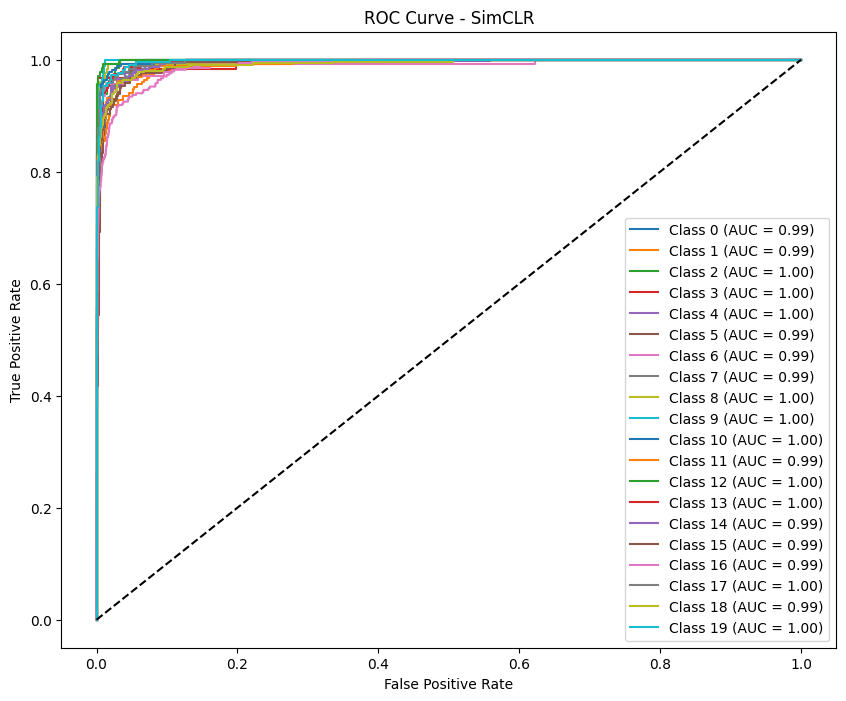

✅ Macro ROC-AUC: 0.9951


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, auc
import torch
import torch.nn.functional as F

backbone.eval()
classifier.eval()

all_labels = []
all_preds = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader_ft:
        images, labels = images.to(device), labels.to(device)
        features = backbone(images)
        outputs = classifier(features)

        probs = F.softmax(outputs, dim=1)
        preds = outputs.argmax(1)

        all_labels.extend(labels.cpu().numpy())
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())

# -----------------------------
# 1️⃣ Test Accuracy
# -----------------------------
test_acc = (torch.tensor(all_preds) == torch.tensor(all_labels)).float().mean().item()
print(f"✅ Test Accuracy: {test_acc:.4f}")

# -----------------------------
# 2️⃣ Confusion Matrix
# -----------------------------
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SimCLR")
plt.show()

# -----------------------------
# 3️⃣ ROC-AUC Curve (One-vs-Rest for multi-class)
# -----------------------------
from sklearn.preprocessing import label_binarize
import numpy as np

num_classes = len(train_dataset_ft.classes)
y_true_bin = label_binarize(all_labels, classes=list(range(num_classes)))
y_probs = np.array(all_probs)

plt.figure(figsize=(10, 8))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SimCLR")
plt.legend()
plt.show()

# -----------------------------
# 4️⃣ Macro ROC-AUC Score
# -----------------------------
macro_auc = roc_auc_score(y_true_bin, y_probs, average="macro")
print(f"✅ Macro ROC-AUC: {macro_auc:.4f}")

In [6]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch

def plot_tsne(backbone, dataloader, class_names, n_samples=2000):
    backbone.eval()
    features, labels = [], []

    with torch.no_grad():
        for imgs, lbls in dataloader:
            imgs = imgs.to(device)
            feats = backbone(imgs)
            features.append(feats.cpu().numpy())
            labels.append(lbls.numpy())
            if sum(len(l) for l in labels) >= n_samples:
                break

    features = np.concatenate(features, axis=0)[:n_samples]
    labels = np.concatenate(labels, axis=0)[:n_samples]

    tsne = TSNE(n_components=2, random_state=42, perplexity=30, n_iter=1000)
    embeddings = tsne.fit_transform(features)

    plt.figure(figsize=(10, 8))
    sns.scatterplot(
        x=embeddings[:, 0], y=embeddings[:, 1],
        hue=[class_names[l] for l in labels],
        palette="tab10", s=30, alpha=0.8
    )
    plt.title("t-SNE Clustering of Features (SimCLR Backbone)")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.show()


In [7]:
from sklearn.manifold import TSNE
import numpy as np
import matplotlib.pyplot as plt

def plot_tsne_simclr(backbone, dataloader, class_names, n_samples=2000):
    """
    Plot t-SNE visualization of features from a SimCLR-pretrained backbone.
    Uses only the backbone (not the projection head).
    """
    backbone.eval()
    feats, labels = [], []

    with torch.no_grad():
        for images, lbls in dataloader:
            images = images.to(device)
            f = backbone(images).cpu().numpy()   # ✅ backbone features only
            feats.append(f)
            labels.extend(lbls.numpy())
            if len(labels) >= n_samples:
                break

    feats = np.concatenate(feats, axis=0)[:n_samples]
    labels = np.array(labels)[:n_samples]

    tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
    feats_2d = tsne.fit_transform(feats)

    plt.figure(figsize=(12, 10))
    scatter = plt.scatter(
        feats_2d[:, 0], feats_2d[:, 1],
        c=labels, cmap="tab20", alpha=0.7, s=20
    )
    plt.legend(
        handles=scatter.legend_elements()[0],
        labels=class_names,
        bbox_to_anchor=(1.05, 1), loc='upper left'
    )
    plt.title("t-SNE Clustering of SimCLR Features")
    plt.show()
